# 06b · Merkezi Limit Teoremi (Central Limit Theorem - CLT)
**Probability Lab** · Limit Theorems Module

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Önceki notebook'ta (Büyük Sayılar Yasası) örneklem ortalamasının **nereye** yakınsadığını (μ'ye) öğrendik.  
> Bu notebook'ta örneklem ortalamasının o hedefin etrafında **nasıl** dalgalandığını öğreneceğiz.  
> Cevap şaşırtıcı: popülasyonun şekli ne olursa olsun (çarpık, iki-modlu, üstel — fark etmez),  
> yeterince büyük örneklemlerde örneklem ortalamalarının dağılımı **Normal dağılıma** yakınsar.  
> Bu, tüm çıkarımsal istatistiğin (güven aralığı, hipotez testi, p-değeri) üzerine kurulduğu temeldir.

**Önkoşul:** Büyük Sayılar Yasası (06a), Normal Dağılım (03), Beklenti/Varyans (05)  
**Veri:**  
- `e-commerce-data.csv` — Perakende sipariş verisi (`Quantity`, `UnitPrice` — sağa çarpık dağılımlar)  
- `yellow_tripdata_2026-01.parquet` — NYC Taksi verisi (`trip_distance`, `fare_amount` — sağa çarpık)  
**Araçlar:** Python (numpy, scipy, seaborn), R (ggplot2), SQL (DuckDB)

---
## 1 · Sezgi: LLN'den CLT'ye — "Nereye"den "Nasıl"a

Büyük Sayılar Yasası (LLN) bize şunu söyledi:
$$\bar{X}_n \to \mu \quad (n \to \infty)$$

Ama bu bize **hiçbir şey söylemiyor**:
- $\bar{X}_n$, $\mu$'nün ne kadar **yakınında**? (100 gözlemle mi, 10.000 gözlemle mi?)
- $\bar{X}_n$'in etrafındaki **dalgalanma nasıl bir şekle** sahip? Simetrik mi, çarpık mı?

Merkezi Limit Teoremi (CLT) tam olarak bu boşluğu dolduruyor. İddiası çarpıcı: $X_i$'lerin
kendi dağılımı ne olursa olsun (Bernoulli, Üstel, aşırı çarpık bir e-ticaret sipariş miktarı
dağılımı — fark etmez), $n$ yeterince büyüdüğünde $\bar{X}_n$'in dağılımı **her zaman** Normal'e
yaklaşır. Bu, olasılık teorisindeki en güçlü ve en şaşırtıcı sonuçlardan biri.

---
## 2 · Formal Tanım

$X_1, X_2, \dots, X_n$ i.i.d. (bağımsız ve özdeş dağılmış), $E[X_i]=\mu$ ve $Var(X_i)=\sigma^2 < \infty$ olsun.

**Standartlaştırılmış CLT:**
$$Z_n = \frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} N(0, 1) \quad (n \to \infty)$$

Yani örneklem ortalamasını standartlaştırdığında ($\mu$'yü çıkar, standart hataya böl), bu
standartlaştırılmış değişken **her zaman** standart normal dağılıma yakınsıyor — $X_i$'lerin
orijinal dağılımı fark etmeksizin.

**Pratik (standartlaştırılmamış) form:**
$$\bar{X}_n \overset{\text{yaklaşık}}{\sim} N\left(\mu, \frac{\sigma^2}{n}\right)$$

Yani $\bar{X}_n$'in kendisi de (yaklaşık olarak) normal dağılıyor — ortalaması $\mu$,
varyansı $\sigma^2/n$ (standart hatanın karesi) olan bir normal dağılım.

---
## 3 · Neden Çalışır? (Sezgisel Açıklama)

Bir toplamı ($X_1+X_2+\dots+X_n$) düşün. Her $X_i$ kendi (belki çok çarpık) dağılımından geliyor.
Ama toplama işlemi bir **evrişim (convolution)** işlemidir — ve olasılık dağılımlarının
evrişimi, orijinal şekillerinden bağımsız olarak "köşeleri yuvarlamaya", "çarpıklığı azaltmaya"
eğilimlidir. Her yeni $X_i$ eklendiğinde, toplamın dağılımı biraz daha "çan şekline" yaklaşır.

**Somut benzetme:** Tek bir zar atışı düzgün (uniform) dağılır — hiç çan şekli yok. Ama iki zarın
toplamı (2-12 arası) zaten üçgen şeklinde bir dağılım oluşturur. Üç zarın toplamı daha da
"yuvarlanır". Bu eğilim devam eder ve $n$ büyüdükçe toplam (ve dolayısıyla ortalama) Normal'e yakınsar.

---
## 4 · Standart Hata (SE) ve Örneklem Büyüklüğünün Etkisi

$$SE = \frac{\sigma}{\sqrt{n}}$$

Bu, örneklem ortalamasının dağılımının standart sapmasıdır (popülasyonun kendi standart
sapması $\sigma$'dan farklı!). $n$ arttıkça:
- Örneklem ortalamalarının **dağılımı daralır** (SE küçülür)
- Ama **şekli** her zaman Normal'e yaklaşmaya devam eder

$\sqrt{n}$ kuralı burada da geçerli: hatayı yarıya indirmek için örneklemi 4 katına çıkarman gerekiyor.

---
## 5 · CLT Ne Zaman "Yavaş" Çalışır?

- **Çarpıklık arttıkça** gereken $n$ artar. Simetrik bir dağılım (örn. Uniform) için $n=30$ bile
  yeterince normal görünebilir; aşırı çarpık bir dağılım (örn. e-ticaret sipariş miktarları,
  gelir dağılımı) için $n=100$'ler bile yetersiz kalabilir.
- **Sonlu varyans şartı kritik:** 06a'da gördüğümüz Cauchy dağılımı gibi $Var(X)=\infty$ olan
  dağılımlarda CLT **hiç çalışmaz** — $n$ ne kadar büyürse büyüsün, örneklem ortalamalarının
  dağılımı Normal'e yakınsamaz (kendisi de Cauchy kalır!).
- Kural of thumb: $n \geq 30$ genelde "güvenli" kabul edilir, ama bu çarpıklığa bağlı bir
  yaklaşıklıktır, matematiksel bir garanti değildir.

---
## 6 · CLT'nin Pratik Sonuçları — Neden Bu Kadar Önemli?

CLT olmasaydı:
- **Güven aralıkları** kurulamazdı (çünkü $\bar{X}_n \pm 1.96 \times SE$ formülü, $\bar{X}_n$'in
  normal dağıldığı varsayımına dayanır)
- **Hipotez testleri** (t-test, z-test) çalışmazdı — bu testler istatistiğin normal (veya t-)
  dağıldığı varsayımıyla p-değeri hesaplar
- **A/B testleri** anlamsız kalırdı — iki grup ortalaması arasındaki farkın dağılımı da CLT
  sayesinde normale yaklaşıyor

Bu yüzden CLT, "istatistiğin neden çalıştığının" temel taşı — popülasyonun kendisi hiç normal
dağılmasa bile (ki çoğu gerçek dünya verisi dağılmaz!), örneklem ortalamaları üzerinden çıkarım
yapabiliyoruz.

---
## 7 · LLN vs CLT — Özet Karşılaştırma

| | Büyük Sayılar Yasası (LLN) | Merkezi Limit Teoremi (CLT) |
|---|---|---|
| Soru | $\bar{X}_n$ **nereye** gidiyor? | $\bar{X}_n$ hedefin etrafında **nasıl** dağılıyor? |
| Sonuç | $\bar{X}_n \to \mu$ (nokta) | $\bar{X}_n \approx N(\mu, \sigma^2/n)$ (dağılım) |
| Gereken şart | $E[\lvert X \rvert] < \infty$ | $Var(X) < \infty$ (daha güçlü şart) |
| Pratik kullanım | Monte Carlo simülasyonu | Güven aralığı, hipotez testi |

---
# 🐍 Python Uygulaması

5 adımda ilerleyeceğiz:
1. **E-Ticaret Verisi** — Aşırı çarpık `Quantity` dağılımından tekrarlı örnekleme, CLT'yi gözlemleme
2. **NYC Taksi Verisi** — `fare_amount` ile aynı deneyi farklı bir gerçek veri setinde tekrarlama
3. **n Arttıkça Yakınsama** — Farklı örneklem büyüklüklerini tek grafikte üst üste bindirme
4. **Standart Hata Küçülmesi** — SE'nin $\sqrt{n}$ ile nasıl küçüldüğünü ampirik olarak doğrulama
5. **Güven Aralığı İnşası** — CLT'yi kullanarak tek bir örneklemden gerçek bir güven aralığı hesaplama

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🛒 Python 1 — E-Ticaret Verisi: Aşırı Çarpık Popülasyondan CLT

**Ne yapıyoruz?**  
`Quantity` (sipariş miktarı) sütunu tipik olarak çok sağa çarpıktır — çoğu sipariş küçük
miktarlarda, birkaç toplu sipariş çok büyük. Bu "çirkin" popülasyondan tekrar tekrar örneklem
alıp ortalamasını hesaplayacağız — CLT'nin popülasyonun şekline rağmen çalıştığını göreceğiz.

Veri yüklendi: 541909 satır
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Popülasyon (Quantity) - N=524516
Ortalama: 7.62, Std: 11.37, Çarpıklık (skew): 3.78


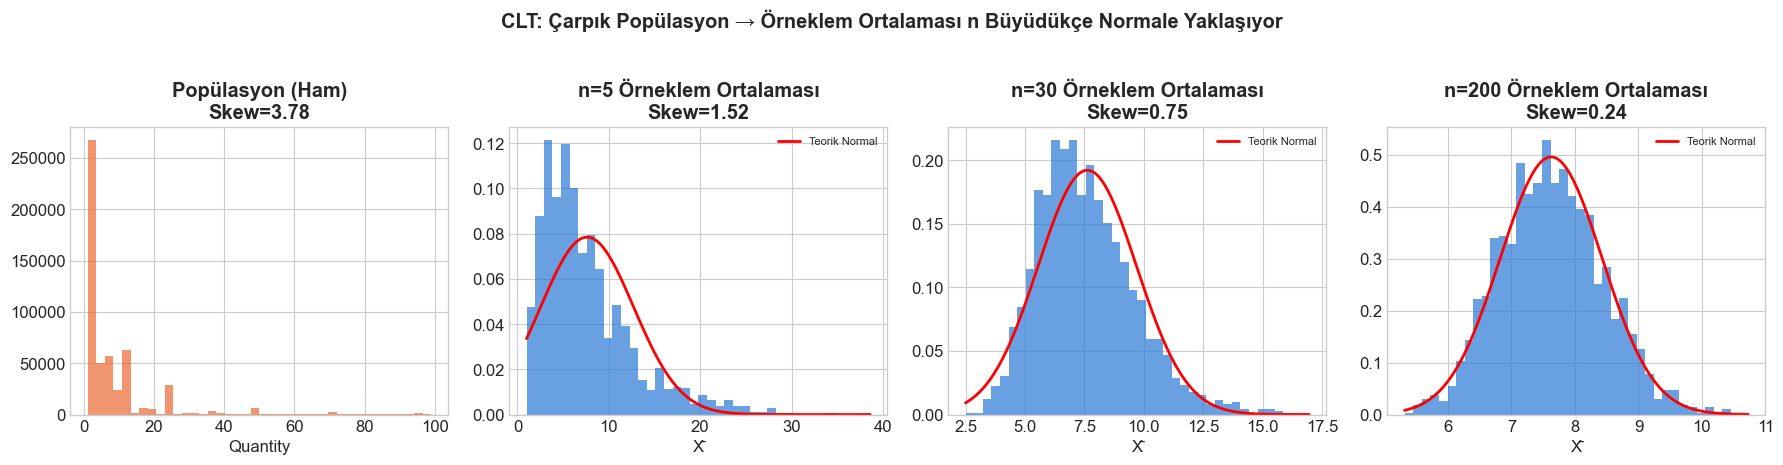


YORUM:
- Ham popülasyon çarpıklığı: 3.78 (0'dan çok uzak, ciddi sağa çarpık)
- n=5'te hâlâ hafif çarpıklık görülüyor
- n=30 ve n=200'de dağılım neredeyse simetrik Normal'e dönüşmüş durumda


In [2]:
ecommerce = pd.read_csv('data/e-commerce-data.csv', encoding='ISO-8859-1')
print(f"Veri yüklendi: {ecommerce.shape[0]} satır")
print(ecommerce.columns.tolist())

# Negatif/sifir miktarlari (iade/hata olabilir) cikaralim, ust %1 ucdegeri de kirpalim
qty = ecommerce['Quantity']
qty_clean = qty[(qty > 0) & (qty < qty.quantile(0.99))]  
print(f"\nPopülasyon (Quantity) - N={len(qty_clean)}")
print(f"Ortalama: {qty_clean.mean():.2f}, Std: {qty_clean.std():.2f}, Çarpıklık (skew): {qty_clean.skew():.2f}")

def sampling_distribution(population, n, n_repeats=2000, rng=None): 
    rng = rng or np.random.default_rng(42)
    pop_arr = population.values
    means = [rng.choice(pop_arr, size=n, replace=True).mean() for _ in range(n_repeats)]
    return np.array(means)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].hist(qty_clean, bins=40, color='#eb6834', alpha=0.7)
axes[0].set_title(f"Popülasyon (Ham)\nSkew={qty_clean.skew():.2f}", fontweight='bold')
axes[0].set_xlabel('Quantity')

for ax, n in zip(axes[1:], [5, 30, 200]):
    means = sampling_distribution(qty_clean, n)
    ax.hist(means, bins=40, color='#2a78d6', alpha=0.7, density=True)
    mu_theory, sigma_theory = qty_clean.mean(), qty_clean.std() / np.sqrt(n)
    x_range = np.linspace(means.min(), means.max(), 200)
    ax.plot(x_range, stats.norm.pdf(x_range, mu_theory, sigma_theory), 'red', linewidth=2, label='Teorik Normal')
    ax.set_title(f"n={n} Örneklem Ortalaması\nSkew={stats.skew(means):.2f}", fontweight='bold')
    ax.set_xlabel('X̄')
    ax.legend(fontsize=8)

plt.suptitle('CLT: Çarpık Popülasyon → Örneklem Ortalaması n Büyüdükçe Normale Yaklaşıyor', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("\nYORUM:")
print(f"- Ham popülasyon çarpıklığı: {qty_clean.skew():.2f} (0'dan çok uzak, ciddi sağa çarpık)")
print("- n=5'te hâlâ hafif çarpıklık görülüyor")
print("- n=30 ve n=200'de dağılım neredeyse simetrik Normal'e dönüşmüş durumda")

---
### 🚕 Python 2 — NYC Taksi Verisi: Gerçek Dünyada İkinci Bir CLT Testi

**Ne yapıyoruz?**  
`fare_amount` (yolculuk ücreti) de tipik olarak sağa çarpıktır (çoğu yolculuk kısa/ucuz, birkaçı
çok uzun/pahalı). Aynı deneyi bambaşka bir gerçek veri setinde tekrarlayarak CLT'nin evrenselliğini
(dağılımdan bağımsız çalıştığını) bir kez daha doğrulayacağız.

Veri yüklendi: 3724889 satır
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']

Popülasyon (fare_amount) - N=3645860
Ortalama: 20.41, Std: 14.97, Çarpıklık: 1.68


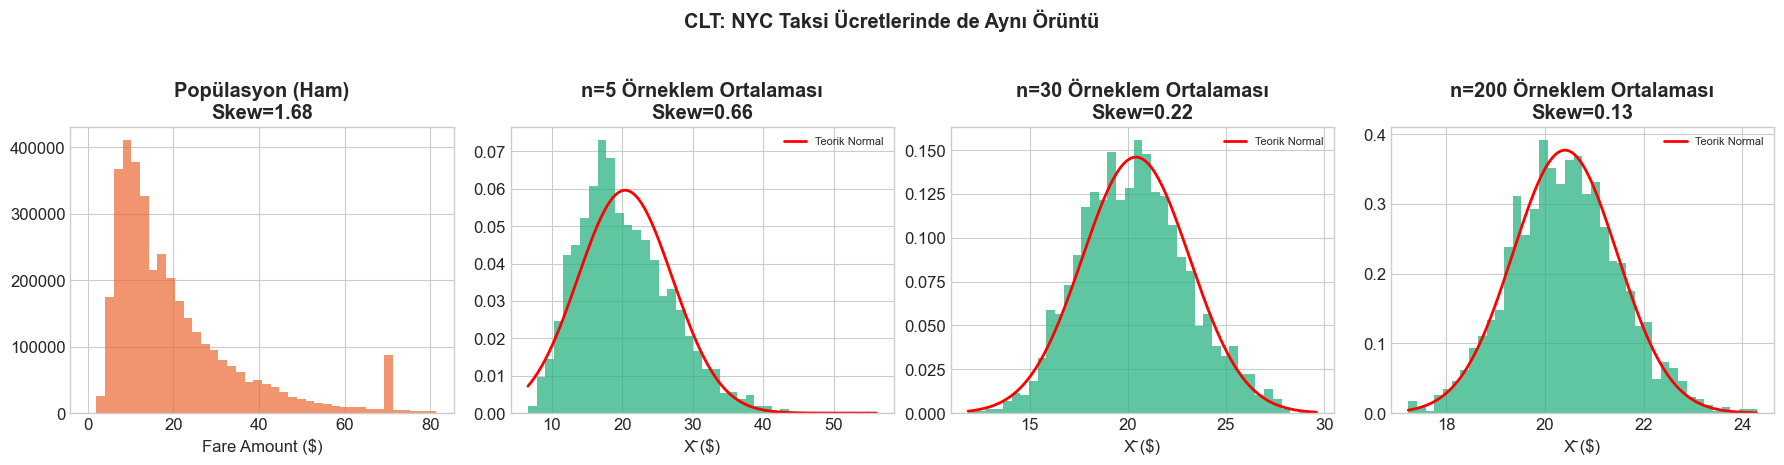


YORUM: Bambaşka bir veri seti, bambaşka bir birim (dolar vs adet) - ama CLT örüntüsü birebir aynı.


In [3]:
taxi = pd.read_parquet('data/yellow_tripdata_2026-01.parquet')
print(f"Veri yüklendi: {taxi.shape[0]} satır")
print(taxi.columns.tolist())

fare = taxi['fare_amount']
fare_clean = fare[(fare > 0) & (fare < fare.quantile(0.99))]
print(f"\nPopülasyon (fare_amount) - N={len(fare_clean)}")
print(f"Ortalama: {fare_clean.mean():.2f}, Std: {fare_clean.std():.2f}, Çarpıklık: {fare_clean.skew():.2f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].hist(fare_clean, bins=40, color='#eb6834', alpha=0.7)
axes[0].set_title(f"Popülasyon (Ham)\nSkew={fare_clean.skew():.2f}", fontweight='bold')
axes[0].set_xlabel('Fare Amount ($)')

for ax, n in zip(axes[1:], [5, 30, 200]):
    means = sampling_distribution(fare_clean, n)
    ax.hist(means, bins=40, color='#1baf7a', alpha=0.7, density=True)
    mu_theory, sigma_theory = fare_clean.mean(), fare_clean.std() / np.sqrt(n)
    x_range = np.linspace(means.min(), means.max(), 200)
    ax.plot(x_range, stats.norm.pdf(x_range, mu_theory, sigma_theory), 'red', linewidth=2, label='Teorik Normal')
    ax.set_title(f"n={n} Örneklem Ortalaması\nSkew={stats.skew(means):.2f}", fontweight='bold')
    ax.set_xlabel('X̄ ($)')
    ax.legend(fontsize=8)

plt.suptitle('CLT: NYC Taksi Ücretlerinde de Aynı Örüntü', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("\nYORUM: Bambaşka bir veri seti, bambaşka bir birim (dolar vs adet) - ama CLT örüntüsü birebir aynı.")

---
### 📈 Python 3 — n Arttıkça Yakınsama Hızı

**Ne yapıyoruz?**  
Tek bir grafikte 6 farklı n değeri (2, 5, 10, 30, 100, 500) için standartlaştırılmış örneklem
ortalaması dağılımlarını üst üste bindirip yakınsamanın akışını tek bakışta görelim.

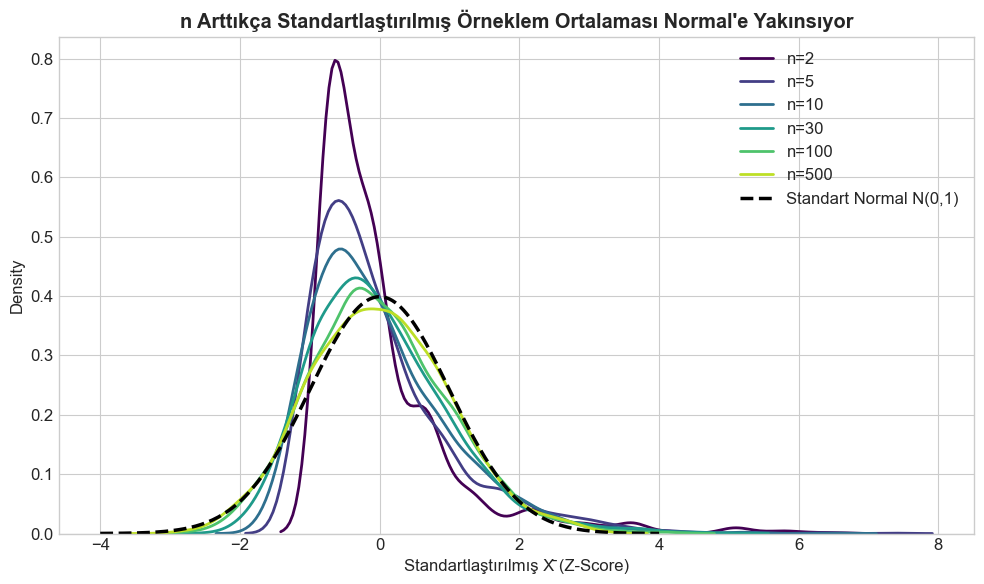

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
n_values = [2, 5, 10, 30, 100, 500]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(n_values)))

for n, color in zip(n_values, colors):
    means = sampling_distribution(qty_clean, n, n_repeats=3000)
    z = (means - means.mean()) / means.std()
    sns.kdeplot(z, ax=ax, color=color, linewidth=2, label=f'n={n}')

x_range = np.linspace(-4, 4, 200)
ax.plot(x_range, stats.norm.pdf(x_range), 'k--', linewidth=2.5, label='Standart Normal N(0,1)')

ax.set_title("n Arttıkça Standartlaştırılmış Örneklem Ortalaması Normal'e Yakınsıyor", fontweight='bold')
ax.set_xlabel('Standartlaştırılmış X̄ (Z-Score)')
ax.legend()
plt.tight_layout()
plt.show()

---
### 📉 Python 4 — Standart Hatanın √n ile Küçülmesi

**Ne yapıyoruz?**  
$SE = \sigma/\sqrt{n}$ formülünü ampirik olarak doğruluyoruz — n arttıkça örneklem ortalamalarının
gerçek standart sapmasının teorik formülle nasıl örtüştüğünü gösteriyoruz.

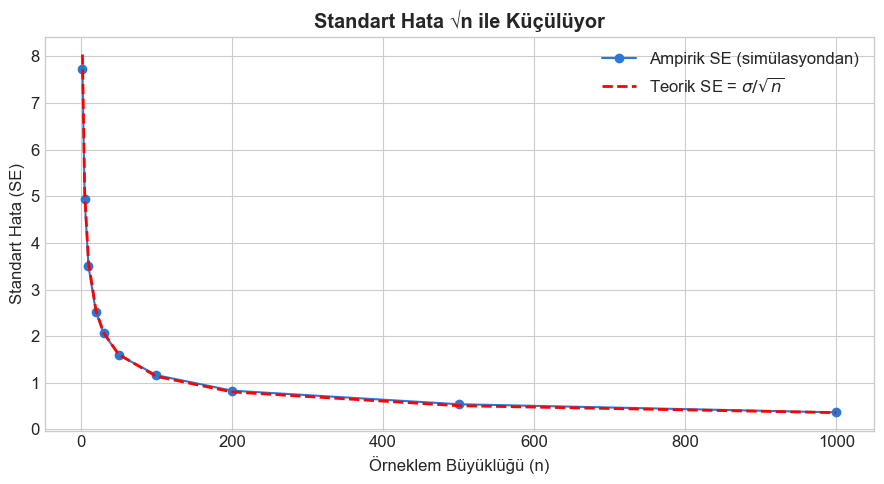

YORUM: n'i 4 katına çıkarmak SE'yi yarıya indiriyor (kare kök ilişkisi).


In [5]:
n_range = np.array([2, 5, 10, 20, 30, 50, 100, 200, 500, 1000])
empirical_se, theoretical_se = [], []
sigma_pop = qty_clean.std()

for n in n_range:
    means = sampling_distribution(qty_clean, n, n_repeats=1000)
    empirical_se.append(means.std())
    theoretical_se.append(sigma_pop / np.sqrt(n))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_range, empirical_se, 'o-', color='#2a78d6', label='Ampirik SE (simülasyondan)')
ax.plot(n_range, theoretical_se, '--', color='red', linewidth=2, label=r'Teorik SE = $\sigma/\sqrt{n}$')
ax.set_xlabel('Örneklem Büyüklüğü (n)')
ax.set_ylabel('Standart Hata (SE)')
ax.set_title("Standart Hata √n ile Küçülüyor", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("YORUM: n'i 4 katına çıkarmak SE'yi yarıya indiriyor (kare kök ilişkisi).")

---
### 🎯 Python 5 — CLT'den Güven Aralığına: Pratik Bir Köprü

**Ne yapıyoruz?**  
Elimizde SADECE tek bir örneklem (n=50) olsaydı, popülasyon ortalaması için %95 güven aralığını
CLT'yi kullanarak nasıl kurardık? Gerçek veriyle deneyip, gerçek popülasyon ortalamasının
aralığın içinde kalıp kalmadığını kontrol edeceğiz.

In [6]:
rng = np.random.default_rng(123)
n_sample = 50
tek_ornek = rng.choice(qty_clean.values, size=n_sample, replace=False)

x_bar = tek_ornek.mean()
s = tek_ornek.std(ddof=1)
se_hat = s / np.sqrt(n_sample)

z_995 = stats.norm.ppf(0.975)  # %95 GA icin 1.96
alt_sinir = x_bar - z_995 * se_hat
ust_sinir = x_bar + z_995 * se_hat

print(f"Tek örneklem ortalaması (X̄): {x_bar:.3f}")
print(f"Tahmini standart hata (SE): {se_hat:.3f}")
print(f"%95 Güven Aralığı: [{alt_sinir:.3f}, {ust_sinir:.3f}]")
print(f"\nGerçek popülasyon ortalaması (μ): {qty_clean.mean():.3f}")
print(f"Gerçek μ, aralığın içinde mi? {'EVET ✓' if alt_sinir <= qty_clean.mean() <= ust_sinir else 'HAYIR ✗'}")

print("\nCLT sayesinde: TEK bir örneklemden, X̄'in etrafındaki güven aralığının Normal dağılıma")
print("dayandırılabileceğini biliyoruz - popülasyonun kendisi hiç normal olmasa bile!")

Tek örneklem ortalaması (X̄): 6.600
Tahmini standart hata (SE): 1.153
%95 Güven Aralığı: [4.340, 8.860]

Gerçek popülasyon ortalaması (μ): 7.625
Gerçek μ, aralığın içinde mi? EVET ✓

CLT sayesinde: TEK bir örneklemden, X̄'in etrafındaki güven aralığının Normal dağılıma
dayandırılabileceğini biliyoruz - popülasyonun kendisi hiç normal olmasa bile!


---
# 📊 R Uygulaması

Python'da yaptığımız e-ticaret örneklem dağılımı deneyini R'da tekrarlayacağız —
`replicate()`/`sapply()` fonksiyonu, Python'daki liste-üretme + örnekleme mantığının R karşılığı.

In [7]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 🛒 R 1 — E-Ticaret Verisinde CLT

**Yeni R kavramı:** `sample(pop, size=n, replace=TRUE)` → Python'daki `rng.choice()` karşılığı.
`gridExtra::grid.arrange()` → birden fazla ggplot'u yan yana koymak için.

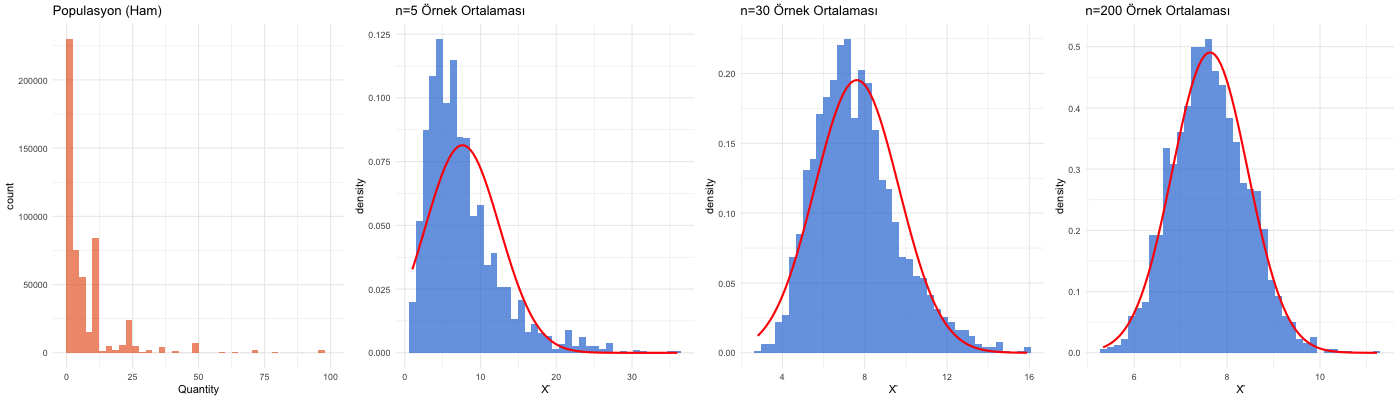

In [8]:
%%R -i qty_clean -w 1400 -h 400

library(ggplot2)
library(gridExtra)

sampling_dist_r <- function(pop, n, repeats = 2000) {
  sapply(1:repeats, function(i) mean(sample(pop, size = n, replace = TRUE)))
}

set.seed(42)
n_values <- c(5, 30, 200)
plots <- list()

p0 <- ggplot(data.frame(x = qty_clean), aes(x = x)) +
  geom_histogram(bins = 40, fill = "#eb6834", alpha = 0.7) +
  labs(title = "Populasyon (Ham)", x = "Quantity") +
  theme_minimal()
plots[[1]] <- p0

for (n in n_values) {
  means <- sampling_dist_r(qty_clean, n)
  df_means <- data.frame(x = means)
  p <- ggplot(df_means, aes(x = x)) +
    geom_histogram(aes(y = after_stat(density)), bins = 40, fill = "#2a78d6", alpha = 0.7) +
    stat_function(fun = dnorm, args = list(mean = mean(means), sd = sd(means)), color = "red", linewidth = 1) +
    labs(title = paste0("n=", n, " Örnek Ortalaması"), x = "X̄") +
    theme_minimal()
  plots[[length(plots) + 1]] <- p
}

grid.arrange(grobs = plots, ncol = 4)

---
# 🗄️ SQL Uygulaması (DuckDB)

Saf SQL'de "1000 kez tekrar örnekleme al" işlemini verimli yapmak için şu kalıbı kullanıyoruz:
1. Popülasyondan yönetilebilir boyutta bir alt-örnek (`USING SAMPLE`) al — tüm shape'i temsil eder
2. Bu alt-örneği "deney" sayısı kadar çarp (`CROSS JOIN`)
3. Her deney içinde `ROW_NUMBER() OVER (PARTITION BY deney_no ORDER BY random())` ile rastgele sırala
4. İlk n satırı al, `GROUP BY deney_no` ile ortalamasını hesapla

Bu, saf SQL'de gerçek "tekrarlı bağımsız örnekleme" sağlayan performanslı bir kalıp.

In [9]:
import duckdb
con = duckdb.connect()
con.register('ecommerce_tbl', ecommerce)
con.register('taxi_tbl', taxi)
print('DuckDB hazır ✓')

DuckDB hazır ✓


---
### 🛒 SQL 1 — Tekrarlı Örnekleme Simülasyonu (DuckDB)

**Ne yapıyoruz?**  
500 "deney" için her birinde n=30'luk rastgele bir örneklem çekip ortalamasını hesaplıyoruz —
sonra 500 deneyin ortalamalarının dağılımına bakıyoruz.

500 deneyin örneklem ortalaması dağılımı (n=30):
count    500.000000
mean      10.195133
std        4.983182
min        3.766667
25%        6.900000
50%        9.033333
75%       11.783333
max       34.100000
Name: ornek_ortalamasi, dtype: float64


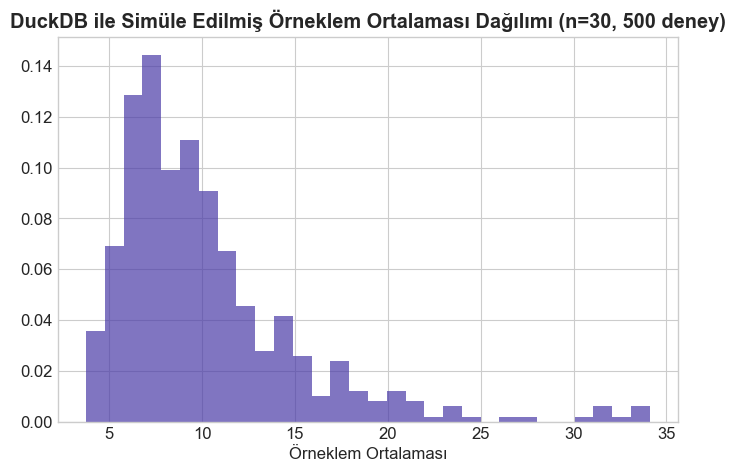

In [10]:
sql_clt = con.execute("""
    WITH pop_sample AS (
        SELECT Quantity FROM ecommerce_tbl WHERE Quantity > 0 USING SAMPLE 2000 ROWS
    ),
    deneyler AS (
        SELECT unnest(range(1, 501)) AS deney_no
    ),
    cross_sample AS (
        SELECT d.deney_no, p.Quantity,
               row_number() OVER (PARTITION BY d.deney_no ORDER BY random()) AS rnk
        FROM deneyler d
        CROSS JOIN pop_sample p
    )
    SELECT deney_no, AVG(Quantity) AS ornek_ortalamasi
    FROM cross_sample
    WHERE rnk <= 30
    GROUP BY deney_no
    ORDER BY deney_no
""").df()

print(f"500 deneyin örneklem ortalaması dağılımı (n=30):")
print(sql_clt['ornek_ortalamasi'].describe())

plt.figure(figsize=(8, 5))
plt.hist(sql_clt['ornek_ortalamasi'], bins=30, color='#4a3aa7', alpha=0.7, density=True)
plt.title('DuckDB ile Simüle Edilmiş Örneklem Ortalaması Dağılımı (n=30, 500 deney)', fontweight='bold')
plt.xlabel('Örneklem Ortalaması')
plt.show()

---
### 📉 SQL 2 — n Arttıkça Standart Hatanın Küçülmesi (SQL'de Doğrulama)

Aynı kalıbı 3 farklı n (10, 30, 100) için tekrarlayıp, örneklem ortalamalarının standart
sapmasının (ampirik SE) küçüldüğünü SQL çıktısında görelim.

In [11]:
sonuclar = []
for n in [10, 30, 100]:
    q = f"""
        WITH pop_sample AS (
            SELECT Quantity FROM ecommerce_tbl WHERE Quantity > 0 USING SAMPLE 2000 ROWS
        ),
        deneyler AS (
            SELECT unnest(range(1, 301)) AS deney_no
        ),
        cross_sample AS (
            SELECT d.deney_no, p.Quantity,
                   row_number() OVER (PARTITION BY d.deney_no ORDER BY random()) AS rnk
            FROM deneyler d
            CROSS JOIN pop_sample p
        )
        SELECT deney_no, AVG(Quantity) AS ornek_ortalamasi
        FROM cross_sample
        WHERE rnk <= {n}
        GROUP BY deney_no
    """
    df_n = con.execute(q).df()
    sonuclar.append({'n': n, 'ampirik_SE': df_n['ornek_ortalamasi'].std(), 'deney_sayisi': len(df_n)})

sonuc_df = pd.DataFrame(sonuclar)
print(sonuc_df)
print("\nYORUM: n arttıkça 'ampirik_SE' küçülüyor - tıpkı teorik sigma/sqrt(n) formülünün öngördüğü gibi.")

     n  ampirik_SE  deney_sayisi
0   10    9.565430           300
1   30    5.953924           300
2  100    2.702637           300

YORUM: n arttıkça 'ampirik_SE' küçülüyor - tıpkı teorik sigma/sqrt(n) formülünün öngördüğü gibi.


---
## ✏️ Egzersizler

### **E1 (Python).** `UnitPrice` sütunu için CLT deneyini tekrarla:
- n=(5, 30, 200) için örneklem dağılımlarını çiz
- n=50'lik tek bir örneklemden %90 güven aralığı kur


=== Egzersiz 1: UnitPrice CLT ===
Popülasyon: N=533880, Ortalama=3.11, Skew=2.03


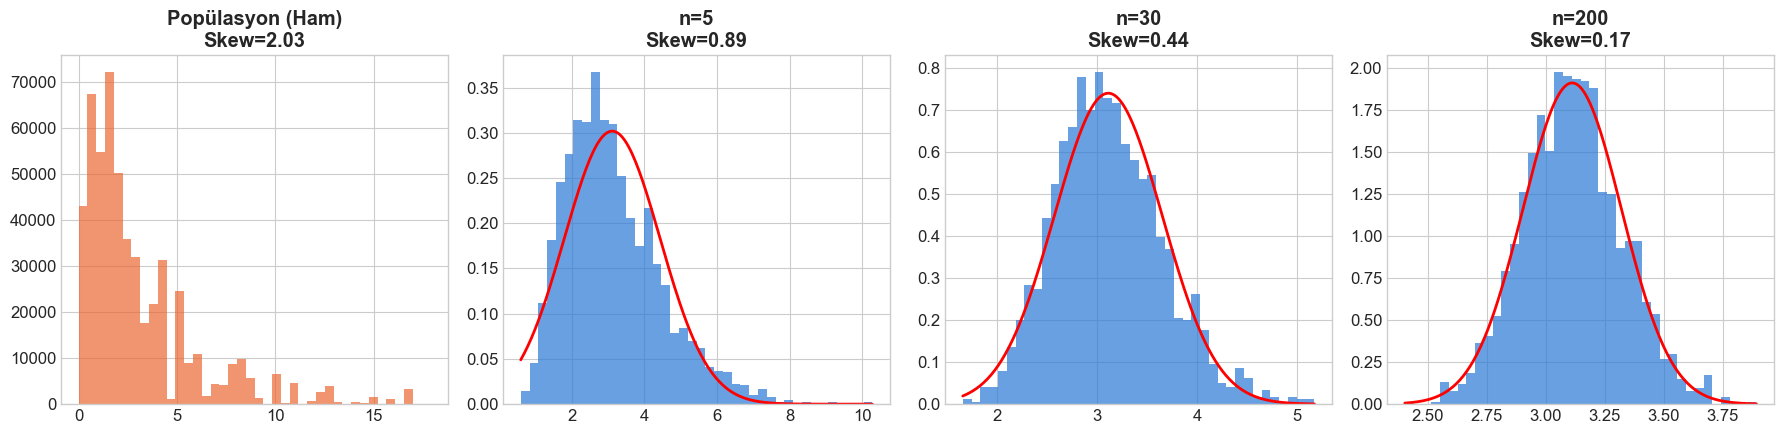


%90 Güven Aralığı: [2.421, 3.266]
Gerçek μ: 3.111


In [21]:
print("=== Egzersiz 1: UnitPrice CLT ===")
price = ecommerce['UnitPrice']
price_clean = price[(price > 0) & (price < price.quantile(0.99))]
print(f"Popülasyon: N={len(price_clean)}, Ortalama={price_clean.mean():.2f}, Skew={price_clean.skew():.2f}")

# CLT simülasyonu ve görselleştirme
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].hist(price_clean, bins=40, color='#eb6834', alpha=0.7)
axes[0].set_title(f"Popülasyon (Ham)\nSkew={price_clean.skew():.2f}", fontweight='bold')
for ax, n in zip(axes[1:], [5, 30, 200]):
    means = sampling_distribution(price_clean, n)
    ax.hist(means, bins=40, color='#2a78d6', alpha=0.7, density=True)
    mu_t, sigma_t = price_clean.mean(), price_clean.std() / np.sqrt(n)
    xr = np.linspace(means.min(), means.max(), 200)
    ax.plot(xr, stats.norm.pdf(xr, mu_t, sigma_t), 'red', linewidth=2)
    ax.set_title(f"n={n}\nSkew={stats.skew(means):.2f}", fontweight='bold')
plt.tight_layout()
plt.show()

# CLT ile örneklem ortalamasının güven aralığını tahmin etme
rng = np.random.default_rng(7)
ornek50 = rng.choice(price_clean.values, size=50, replace=False)
x_bar, s = ornek50.mean(), ornek50.std(ddof=1)
se = s / np.sqrt(50)
z90 = stats.norm.ppf(0.90)
print(f"\n%90 Güven Aralığı: [{x_bar - z90*se:.3f}, {x_bar + z90*se:.3f}]")
print(f"Gerçek μ: {price_clean.mean():.3f}")

---
### **E2 (Python).** NYC Taksi `trip_distance` sütununda **coverage deneyi** yap:
- 100 kez, her seferinde n=40'lık bir örneklem çek ve %95 GA kur
- Gerçek popülasyon ortalamasının kaç aralığın İÇİNDE kaldığını say
- Oran ~%95'e yakın mı? (CLT'nin garantisinin ampirik testi!)

In [13]:
print("\n\n=== Egzersiz 2: Coverage Deneyi (trip_distance) ===")
dist = taxi['trip_distance']
dist_clean = dist[(dist > 0) & (dist < dist.quantile(0.99))]
mu_gercek = dist_clean.mean()

icinde_kalan = 0
n_deney = 100
rng2 = np.random.default_rng(99)
for _ in range(n_deney):
    ornek = rng2.choice(dist_clean.values, size=40, replace=False)
    xb, ss = ornek.mean(), ornek.std(ddof=1)
    se_ = ss / np.sqrt(40)
    alt, ust = xb - 1.96*se_, xb + 1.96*se_
    if alt <= mu_gercek <= ust:
        icinde_kalan += 1

print(f"Gerçek μ (trip_distance): {mu_gercek:.3f}")
print(f"{n_deney} denemeden {icinde_kalan} tanesinde gerçek μ, %95 GA içinde kaldı")
print(f"Coverage oranı: {icinde_kalan/n_deney:.1%} (teorik olarak ~%95 bekleniyor)")



=== Egzersiz 2: Coverage Deneyi (trip_distance) ===
Gerçek μ (trip_distance): 3.277
100 denemeden 96 tanesinde gerçek μ, %95 GA içinde kaldı
Coverage oranı: 96.0% (teorik olarak ~%95 bekleniyor)


---
### **E3 (SQL).** 
`taxi_tbl`'de `fare_amount` için SQL 1'deki cross-join kalıbını tekrarla
(n=30, 500 deney). Sonucu e-ticaret sonucuyla karşılaştır — şekil benzer mi?


=== Egzersiz 3 (SQL): NYC Taksi fare_amount CLT ===
count    500.000000
mean      21.832768
std        3.273480
min       14.175333
25%       19.630750
50%       21.624000
75%       23.755500
max       34.107333
Name: ornek_ortalamasi, dtype: float64


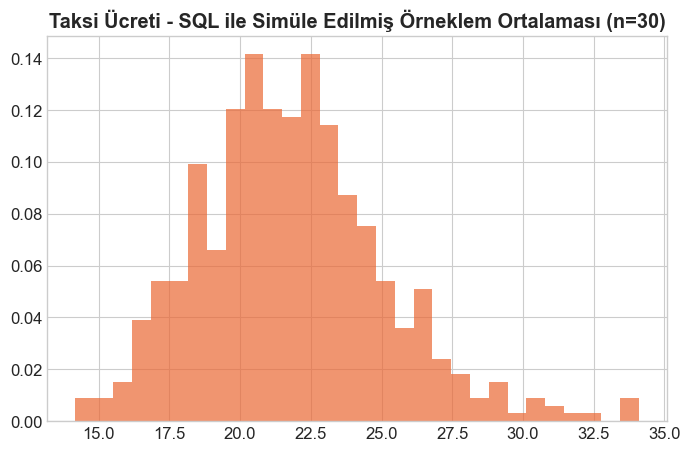


YORUM: Şekil (çan eğrisi) e-ticaret sonucuyla aynı örüntüde - farklı birim/veri ama aynı CLT davranışı.


In [14]:
print("=== Egzersiz 3 (SQL): NYC Taksi fare_amount CLT ===")
sql_ex3 = con.execute("""
    WITH pop_sample AS (
        SELECT fare_amount FROM taxi_tbl WHERE fare_amount > 0 USING SAMPLE 2000 ROWS
    ),
    deneyler AS (
        SELECT unnest(range(1, 501)) AS deney_no
    ),
    cross_sample AS (
        SELECT d.deney_no, p.fare_amount,
               row_number() OVER (PARTITION BY d.deney_no ORDER BY random()) AS rnk
        FROM deneyler d
        CROSS JOIN pop_sample p
    )
    SELECT deney_no, AVG(fare_amount) AS ornek_ortalamasi
    FROM cross_sample
    WHERE rnk <= 30
    GROUP BY deney_no
    ORDER BY deney_no
""").df()

print(sql_ex3['ornek_ortalamasi'].describe())
plt.figure(figsize=(8, 5))
plt.hist(sql_ex3['ornek_ortalamasi'], bins=30, color='#eb6834', alpha=0.7, density=True)
plt.title('Taksi Ücreti - SQL ile Simüle Edilmiş Örneklem Ortalaması (n=30)', fontweight='bold')
plt.show()
print("\nYORUM: Şekil (çan eğrisi) e-ticaret sonucuyla aynı örüntüde - farklı birim/veri ama aynı CLT davranışı.")

---
### **E4 (R).** 
NYC taksi `trip_distance` verisini Python ile temizle ve filtrele, n=30 örneklem ortalamaları
dağılımı için `qqnorm()` + `qqline()` çiz. Noktalar çizgiye ne kadar yakın?

In [17]:
# Sadece ihtiyacımız olan sütunu seçip kopyalıyoruz
dist_python = taxi['trip_distance'].dropna()

# %99'luk dilim filtresini Python'da hızlıca uyguluyoruz
q99 = dist_python.quantile(0.99)
dist_python = dist_python[(dist_python > 0) & (dist_python < q99)]

# R'a tüm tablo yerine sadece bu temiz sayı dizisini (vektörü) gönderiyoruz
dist_r_clean = dist_python.to_numpy()


Hesaplanan R² (R-Kare) Değeri: 0.9838
R² değeri 1'e ne kadar yakınsa, n=30 için dağılım o kadar Normal dağılıma uygundur.
Noktalar çizgiye çok yakınsa: n=30 örneklem ortalaması dağılımı zaten Normal'e çok yakın demektir.


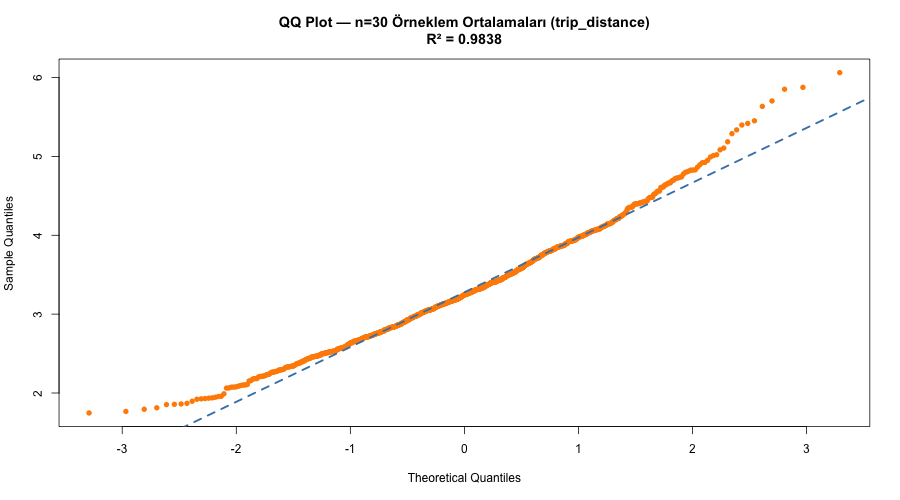

In [22]:
%%R -i dist_r_clean -w 900 -h 500

set.seed(2026)

sampling_dist_r <- function(pop, n, repeats = 1000) {
  sapply(1:repeats, function(i) mean(sample(pop, size = n, replace = TRUE)))
}

# Örneklem ortalamalarını hesaplama
means_30 <- sampling_dist_r(dist_r_clean, 30)

# Kuantil değerlerini arka planda hesaplama
r <- qqnorm(means_30, plot.it = FALSE)

# Lineer model kurarak R-kare (R²) değerini çıkarma
model <- lm(r$y ~ r$x)
r_squared <- summary(model)$r.squared

# Dinamik başlık oluşturma (R² değerini başlığa ekler)
baslik <- paste0("QQ Plot — n=30 Örneklem Ortalamaları (trip_distance)\nR² = ", round(r_squared, 4))

# Grafik çizimi
qqnorm(means_30, main = baslik, col = "darkorange", pch = 16)
qqline(means_30, col = "steelblue", lwd = 2.5, lty = 2)

# Konsola çıktı basma
cat(sprintf("Hesaplanan R² (R-Kare) Değeri: %0.4f\n", r_squared))
cat("R² değeri 1'e ne kadar yakınsa, n=30 için dağılım o kadar Normal dağılıma uygundur.\n")


cat("Noktalar çizgiye çok yakınsa: n=30 örneklem ortalaması dağılımı zaten Normal'e çok yakın demektir.\n")


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 8–9 | Central Limit Theorem |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | Ders 33–34 | CLT, normal yaklaşım |
| [Seeing Theory](https://seeing-theory.brown.edu/probability-distributions/index.html#section3) | CLT simülasyonu | İnteraktif — farklı dağılımlarla deneme |
| [StatQuest — CLT](https://www.youtube.com/watch?v=YAlJCEDH2uY) | Video | Görsel sezgi |
| [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) | Veri | Taksi verisi resmi kaynağı |
| [UCI Online Retail Dataset](https://archive.ics.uci.edu/dataset/352/online+retail) | Veri | E-ticaret veri seti kaynağı (e-commerce-data.csv'nin kökeni) |